In [36]:
import pandas as pd
import numpy as np

In [37]:
df1 = pd.read_csv("data/churn_cleaned.csv")

In [38]:
df1.head()

,CreditScore,Age,Balance,NumOfProducts,IsActiveMember,Exited,ZeroBalance,ProductActivity,BalanceSalaryRatio,Gender_Encoded,Geography_Germany,Geography_Spain,TenureAgeRatio
0,619,42,0.00,1,1,1,1,1,0.000000,0,0.0,0.0,0.059524
1,608,41,83807.86,1,1,0,0,1,0.744670,0,0.0,1.0,0.036585
2,502,42,159660.80,3,0,1,0,0,1.401362,0,0.0,0.0,0.202381
3,699,39,0.00,2,0,0,1,0,0.000000,0,0.0,0.0,0.038462
4,850,43,125510.82,1,1,0,0,1,1.587035,0,0.0,1.0,0.058140


In [39]:
# Verify ZeroBalance is consistent with Balance
print(df1[df1['Balance'] == 0]['ZeroBalance'].value_counts())

ZeroBalance
1    3617
Name: count, dtype: int64


In [40]:
df1.shape

(10000, 13)

In [41]:
X = df1.drop(columns=['Exited'])
y = df1['Exited']

In [42]:
from sklearn.model_selection import train_test_split

In [43]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [44]:
print(X_train.shape, X_test.shape)

(8000, 12) (2000, 12)


In [45]:
from sklearn.preprocessing import StandardScaler

In [46]:
scaler = StandardScaler()

In [47]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

In [48]:
from sklearn.linear_model import LogisticRegression

In [49]:
lr = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)

In [50]:
lr.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [51]:
y_pred_lr = lr.predict(X_test_scaled)

In [52]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

In [53]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.90      0.71      0.80      1593
           1       0.38      0.70      0.49       407

    accuracy                           0.71      2000
   macro avg       0.64      0.71      0.65      2000
weighted avg       0.80      0.71      0.73      2000



In [54]:
print("ROC-AUC:", roc_auc_score(y_test, lr.predict_proba(X_test_scaled)[:, 1]))

ROC-AUC: 0.7772579975969806


In [55]:
import matplotlib.pyplot as plt
import seaborn as sns

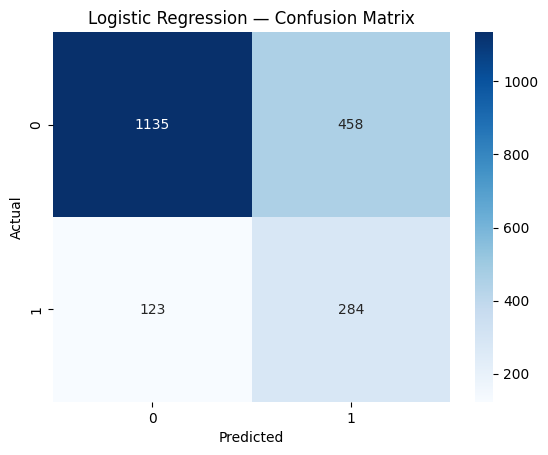

In [56]:
cm = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression — Confusion Matrix")
plt.show()

In [57]:
from sklearn.ensemble import RandomForestClassifier

In [58]:
rf = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42
)

In [59]:
rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [60]:
y_pred_rf = rf.predict(X_test)

In [61]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.87      0.97      0.92      1593
           1       0.78      0.45      0.57       407

    accuracy                           0.86      2000
   macro avg       0.83      0.71      0.75      2000
weighted avg       0.85      0.86      0.85      2000



In [62]:
print("ROC-AUC:", roc_auc_score(y_test, rf.predict_proba(X_test)[:, 1]))

ROC-AUC: 0.8421526302882236


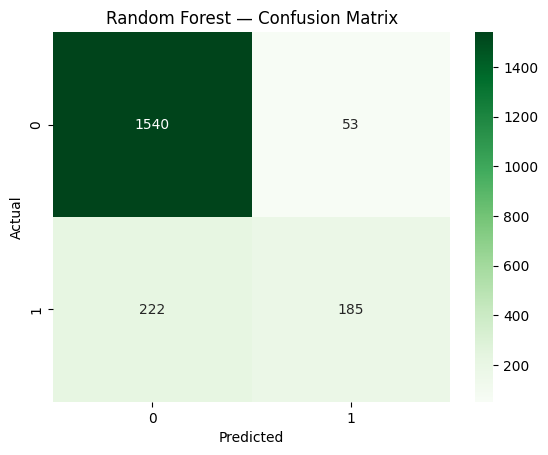

In [63]:
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest — Confusion Matrix")
plt.show()

In [64]:
importances = pd.Series(rf.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False)
print(importances)

Age                   0.247957
CreditScore           0.139942
TenureAgeRatio        0.139536
Balance               0.119284
NumOfProducts         0.107667
BalanceSalaryRatio    0.102314
ProductActivity       0.046881
Geography_Germany     0.031229
IsActiveMember        0.021224
Gender_Encoded        0.021085
Geography_Spain       0.014894
ZeroBalance           0.007987
dtype: float64


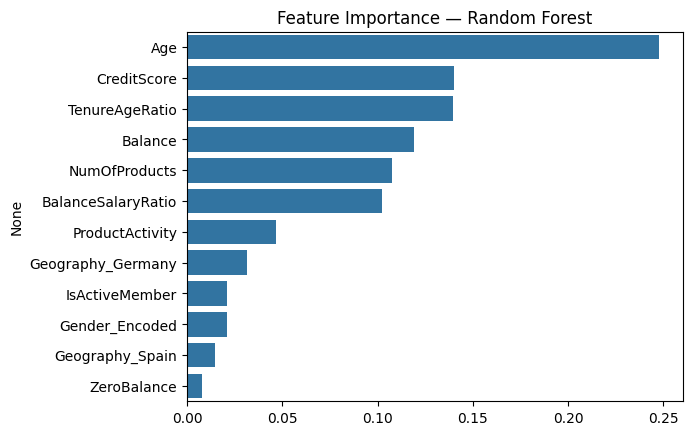

In [65]:
sns.barplot(x=importances.values, y=importances.index)
plt.title("Feature Importance — Random Forest")
plt.show()

In [99]:
from sklearn.model_selection import RandomizedSearchCV

In [100]:
rf_param_grid = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

In [101]:
rf_search = RandomizedSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42),
    param_distributions=rf_param_grid,
    n_iter=50,
    scoring='roc_auc',
    cv=5,
    random_state=42,
    n_jobs=-1
)

In [102]:
rf_search.fit(X_train, y_train)

,estimator,RandomForestC...ndom_state=42)
,param_distributions,"{'max_depth': [5, 10, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,n_iter,50
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [103]:
print("Best params:", rf_search.best_params_)
print("Best CV ROC-AUC:", round(rf_search.best_score_, 3))

Best params: {'n_estimators': 500, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_features': 'log2', 'max_depth': 10}
Best CV ROC-AUC: 0.862


In [104]:
rf_best = rf_search.best_estimator_

In [105]:
y_pred_rf_best = rf_best.predict(X_test)
print(classification_report(y_test, y_pred_rf_best))

              precision    recall  f1-score   support

           0       0.92      0.87      0.89      1593
           1       0.58      0.69      0.63       407

    accuracy                           0.83      2000
   macro avg       0.75      0.78      0.76      2000
weighted avg       0.85      0.83      0.84      2000



In [106]:
print("ROC-AUC:", roc_auc_score(y_test, rf_best.predict_proba(X_test)[:, 1]))

ROC-AUC: 0.8664303749049512


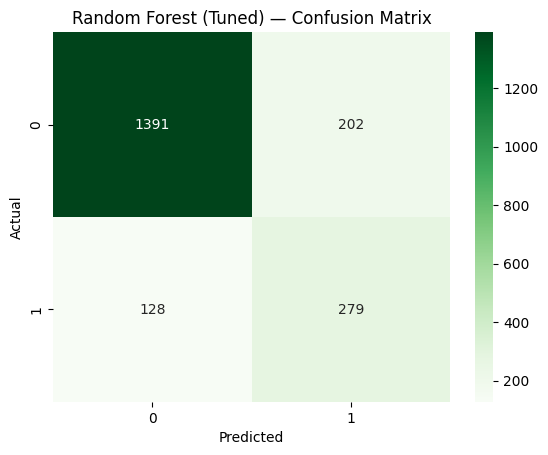

In [107]:
cm_rf_best = confusion_matrix(y_test, y_pred_rf_best)
sns.heatmap(cm_rf_best, annot=True, fmt='d', cmap='Greens')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest (Tuned) — Confusion Matrix")
plt.show()

In [66]:
from sklearn.metrics import precision_recall_curve

In [67]:
y_proba_rf = rf.predict_proba(X_test)[:, 1]

precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba_rf)

In [68]:
# Find the threshold where F1 is maximized
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print(f"Best threshold: {best_threshold:.3f}")
print(f"At this threshold — Precision: {precisions[best_idx]:.3f}, Recall: {recalls[best_idx]:.3f}, F1: {f1_scores[best_idx]:.3f}")

Best threshold: 0.290
At this threshold — Precision: 0.555, Recall: 0.668, F1: 0.606


In [69]:
# Apply the optimized threshold
y_pred_rf_tuned = (y_proba_rf >= best_threshold).astype(int)

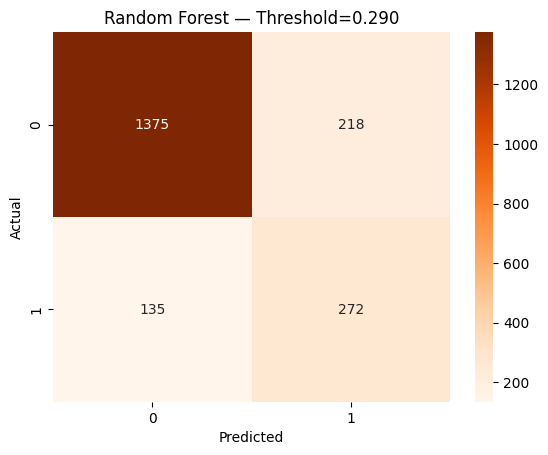

In [70]:
cm_tuned = confusion_matrix(y_test, y_pred_rf_tuned)
sns.heatmap(cm_tuned, annot=True, fmt='d', cmap='Oranges')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Random Forest — Threshold={best_threshold:.3f}")
plt.show()

In [75]:
from sklearn.model_selection import cross_val_score

In [76]:
cv_scores = cross_val_score(rf, X, y, cv=5, scoring='roc_auc')
print(f"CV ROC-AUC scores: {cv_scores.round(3)}")
print(f"Mean: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")

CV ROC-AUC scores: [0.848 0.858 0.851 0.845 0.843]
Mean: 0.849 ± 0.005


# XGBoost

In [78]:
from xgboost import XGBClassifier

In [79]:
# scale_pos_weight handles class imbalance — ratio of majority/minority
scale = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight: {scale:.2f}")

scale_pos_weight: 3.91


In [80]:
xgb = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    scale_pos_weight=scale,
    random_state=42,
    eval_metric='logloss'
)

In [81]:
xgb.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [82]:
y_pred_xgb = xgb.predict(X_test)

In [83]:
print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.92      0.85      0.89      1593
           1       0.56      0.72      0.63       407

    accuracy                           0.83      2000
   macro avg       0.74      0.79      0.76      2000
weighted avg       0.85      0.83      0.83      2000



In [85]:
print("ROC-AUC:", roc_auc_score(y_test, xgb.predict_proba(X_test)[:, 1]))

ROC-AUC: 0.8617862855150991


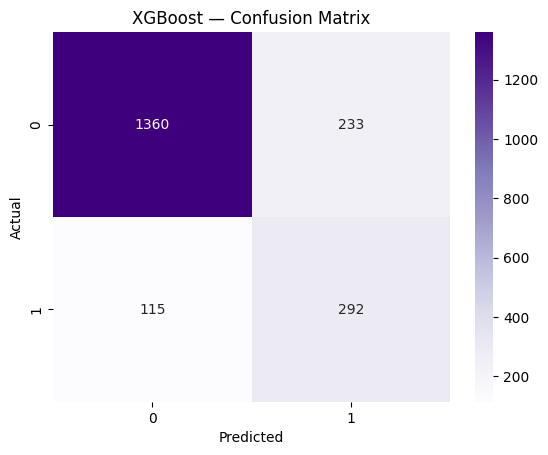

In [86]:
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Purples')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("XGBoost — Confusion Matrix")
plt.show()

In [87]:
from sklearn.model_selection import RandomizedSearchCV

In [88]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7, 9],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'min_child_weight': [1, 3, 5]
}

In [89]:
xgb_search = RandomizedSearchCV(
    XGBClassifier(scale_pos_weight=scale, random_state=42, eval_metric='logloss'),
    param_distributions=param_grid,
    n_iter=50,
    scoring='roc_auc',
    cv=5,
    random_state=42,
    n_jobs=-1
)

In [90]:
xgb_search.fit(X_train, y_train)

,estimator,"XGBClassifier...ree=None, ...)"
,param_distributions,"{'colsample_bytree': [0.7, 0.8, ...], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 5, ...], 'min_child_weight': [1, 3, ...], ...}"
,n_iter,50
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [91]:
print("Best params:", xgb_search.best_params_)
print("Best CV ROC-AUC:", round(xgb_search.best_score_, 3))

Best params: {'subsample': 0.7, 'n_estimators': 300, 'min_child_weight': 1, 'max_depth': 5, 'learning_rate': 0.01, 'colsample_bytree': 0.7}
Best CV ROC-AUC: 0.865


In [92]:
xgb_best = xgb_search.best_estimator_

In [93]:
y_pred_xgb_best = xgb_best.predict(X_test)
print(classification_report(y_test, y_pred_xgb_best))

              precision    recall  f1-score   support

           0       0.93      0.82      0.87      1593
           1       0.52      0.76      0.62       407

    accuracy                           0.81      2000
   macro avg       0.73      0.79      0.75      2000
weighted avg       0.85      0.81      0.82      2000



In [95]:
print("ROC-AUC:", roc_auc_score(y_test, xgb_best.predict_proba(X_test)[:, 1]))

ROC-AUC: 0.8703834805529721


In [96]:
#Threshold Tuning on Best Model
y_proba_best = xgb_best.predict_proba(X_test)[:, 1]

precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba_best)

f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print(f"Optimal threshold: {best_threshold:.3f}")
print(f"Precision: {precisions[best_idx]:.3f}, Recall: {recalls[best_idx]:.3f}, F1: {f1_scores[best_idx]:.3f}")

Optimal threshold: 0.655
Precision: 0.702, Recall: 0.602, F1: 0.648


In [97]:
y_pred_final = (y_proba_best >= best_threshold).astype(int)
print(classification_report(y_test, y_pred_final))

              precision    recall  f1-score   support

           0       0.90      0.93      0.92      1593
           1       0.70      0.60      0.65       407

    accuracy                           0.87      2000
   macro avg       0.80      0.77      0.78      2000
weighted avg       0.86      0.87      0.86      2000



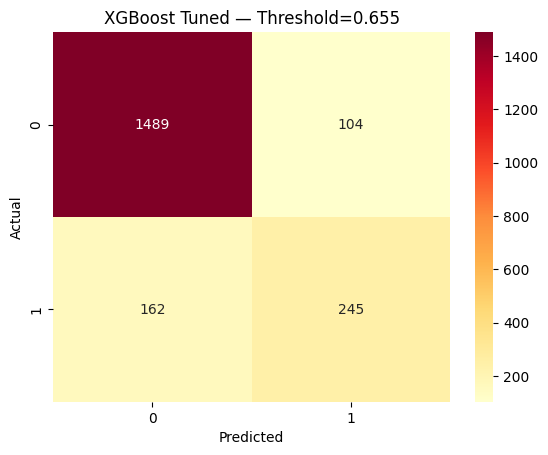

In [98]:
cm_final = confusion_matrix(y_test, y_pred_final)
sns.heatmap(cm_final, annot=True, fmt='d', cmap='YlOrRd')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"XGBoost Tuned — Threshold={best_threshold:.3f}")
plt.show()

In [108]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Final Summary DataFrame
summary_df = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Random Forest (Baseline)',
        'Random Forest (Tuned)',
        'XGBoost (Baseline)',
        'XGBoost (Tuned + Threshold 0.655)'
    ],
    'Accuracy': [0.71, 0.86, 0.83, 0.83, 0.87],
    'Precision (Churn)': [0.38, 0.78, 0.58, 0.56, 0.70],
    'Recall (Churn)': [0.70, 0.45, 0.69, 0.72, 0.60],
    'F1-Score (Churn)': [0.49, 0.57, 0.63, 0.63, 0.65],
    'ROC-AUC': [0.777, 0.842, 0.866, 0.862, 0.870]
})

display(summary_df)

,Model,Accuracy,Precision (Churn),Recall (Churn),F1-Score (Churn),ROC-AUC
0,Logistic Regression,0.71,0.38,0.70,0.49,0.777
1,Random Forest (Baseline),0.86,0.78,0.45,0.57,0.842
2,Random Forest (Tuned),0.83,0.58,0.69,0.63,0.866
3,XGBoost (Baseline),0.83,0.56,0.72,0.63,0.862
4,XGBoost (Tuned + Threshold 0.655),0.87,0.70,0.60,0.65,0.870


C:\Users\tejas\AppData\Local\Temp\ipykernel_14360\806072100.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='ROC-AUC', y='Model', data=summary_df, palette='viridis')


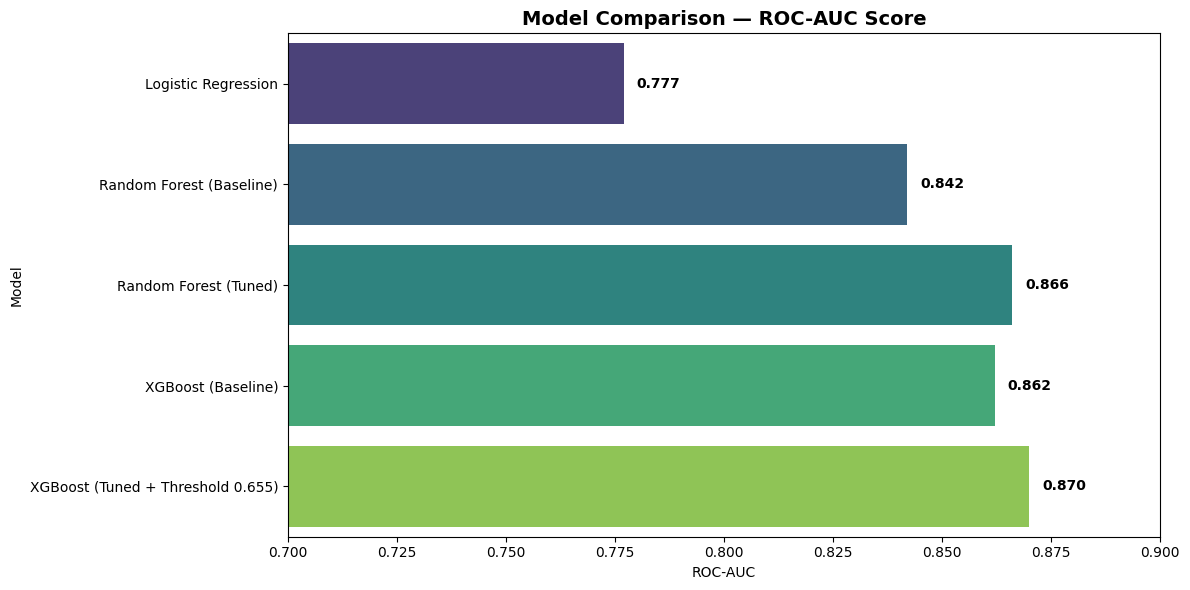

In [109]:
# Visual Comparison Plot
plt.figure(figsize=(12, 6))
sns.barplot(x='ROC-AUC', y='Model', data=summary_df, palette='viridis')
plt.title("Model Comparison — ROC-AUC Score", fontsize=14, fontweight='bold')
plt.xlim(0.70, 0.90)
for index, value in enumerate(summary_df['ROC-AUC']):
    plt.text(value + 0.003, index, f"{value:.3f}", va='center', fontweight='bold')
plt.tight_layout()
plt.show()

In [113]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import pandas as pd

# Helper function to extract all metrics directly from predictions & probabilities
def evaluate_model(name, y_true, y_pred, y_prob):
    return {
        'Model Variant': name,
        'Accuracy': round(accuracy_score(y_true, y_pred), 3),
        'Precision (Churn)': round(precision_score(y_true, y_pred, pos_label=1), 3),
        'Recall (Churn)': round(recall_score(y_true, y_pred, pos_label=1), 3),
        'F1-Score (Churn)': round(f1_score(y_true, y_pred, pos_label=1), 3),
        'ROC-AUC': round(roc_auc_score(y_true, y_prob), 3)
    }

# 1. Probabilities for all models
p_lr = lr.predict_proba(X_test_scaled)[:, 1]
p_rf_base = rf.predict_proba(X_test)[:, 1]
p_rf_best = rf_best.predict_proba(X_test)[:, 1]
p_xgb_base = xgb.predict_proba(X_test)[:, 1]
p_xgb_best = xgb_best.predict_proba(X_test)[:, 1]

# 2. Predictions & Threshold Variants
pred_lr = lr.predict(X_test_scaled)
pred_rf_base = rf.predict(X_test)
pred_rf_best = rf_best.predict(X_test)
pred_rf_threshold = (p_rf_base >= 0.290).astype(int)  # Optimal threshold on RF
pred_xgb_base = xgb.predict(X_test)
pred_xgb_best = xgb_best.predict(X_test)
pred_xgb_threshold = (p_xgb_best >= 0.655).astype(int) # Optimal threshold on XGBoost

# 3. Evaluate ALL models dynamically
models_eval = [
    evaluate_model('Logistic Regression (Default 0.5)', y_test, pred_lr, p_lr),
    evaluate_model('Random Forest (Baseline 0.5)', y_test, pred_rf_base, p_rf_base),
    evaluate_model('Random Forest (Tuned 0.5)', y_test, pred_rf_best, p_rf_best),
    evaluate_model('Random Forest (Threshold 0.290)', y_test, pred_rf_threshold, p_rf_base),
    evaluate_model('XGBoost (Baseline 0.5)', y_test, pred_xgb_base, p_xgb_base),
    evaluate_model('XGBoost (Tuned 0.5)', y_test, pred_xgb_best, p_xgb_best),
    evaluate_model('XGBoost (Tuned + Threshold 0.655)', y_test, pred_xgb_threshold, p_xgb_best)
]

# 4. Create and display Master Comparison DataFrame
master_comparison_df = pd.DataFrame(models_eval)
master_comparison_df = master_comparison_df.sort_values(by='ROC-AUC', ascending=False).reset_index(drop=True)

display(master_comparison_df)

,Model Variant,Accuracy,Precision (Churn),Recall (Churn),F1-Score (Churn),ROC-AUC
0,XGBoost (Tuned 0.5),0.810,0.523,0.757,0.618,0.870
1,XGBoost (Tuned + Threshold 0.655),0.867,0.702,0.602,0.648,0.870
2,Random Forest (Tuned 0.5),0.835,0.580,0.686,0.628,0.866
3,XGBoost (Baseline 0.5),0.826,0.556,0.717,0.627,0.862
4,Random Forest (Baseline 0.5),0.863,0.777,0.455,0.574,0.842
5,Random Forest (Threshold 0.290),0.824,0.555,0.668,0.606,0.842
6,Logistic Regression (Default 0.5),0.710,0.383,0.698,0.494,0.777


C:\Users\tejas\AppData\Local\Temp\ipykernel_14360\863186622.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='ROC-AUC', y='Model Variant', data=master_comparison_df, palette='Blues_r')


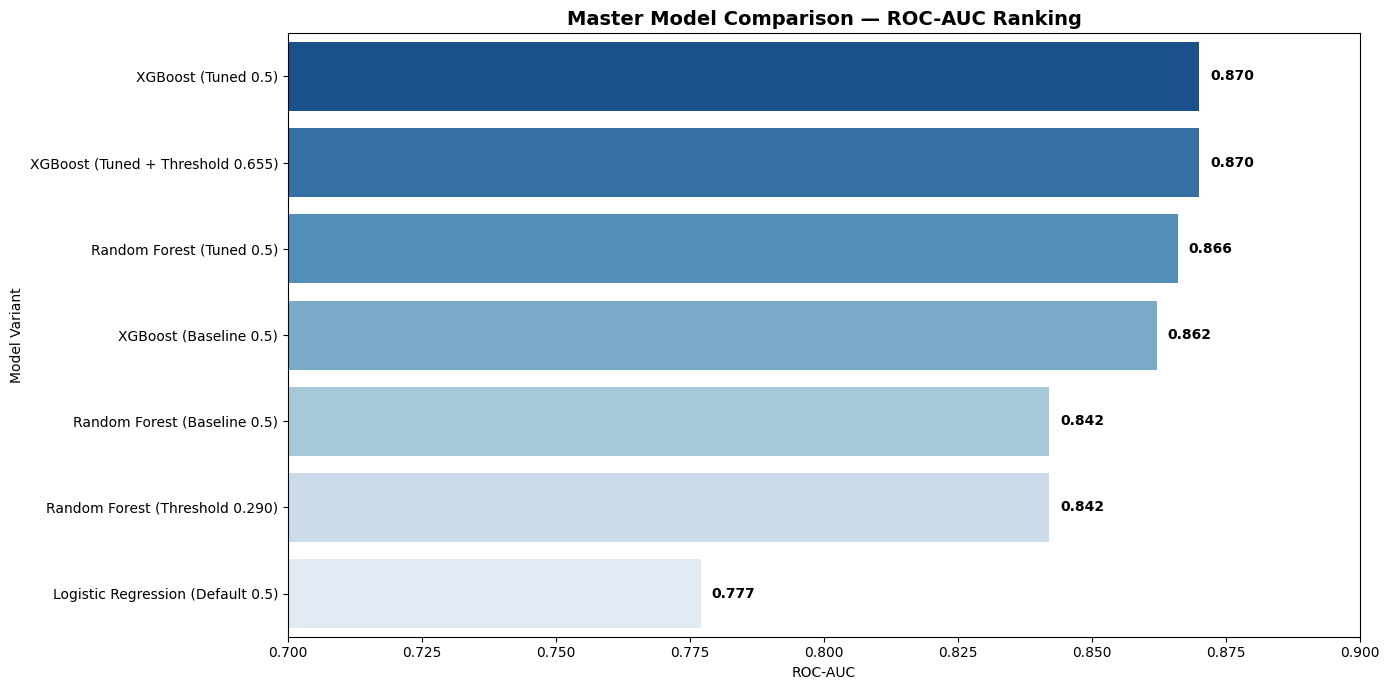

In [114]:
# Master Comparison Plot
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 7))
ax = sns.barplot(x='ROC-AUC', y='Model Variant', data=master_comparison_df, palette='Blues_r')
plt.title("Master Model Comparison — ROC-AUC Ranking", fontsize=14, fontweight='bold')
plt.xlim(0.70, 0.90)

for p in ax.patches:
    width = p.get_width()
    ax.annotate(f"{width:.3f}", 
                (width + 0.002, p.get_y() + p.get_height() / 2.),
                ha='left', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()